In [3]:
# load in libary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# load the dataset
dataset = pd.read_csv('clean_crimedata.csv')
dataset.head()

,crimeOccurence,Community.Name,state,countyCode,communityCode,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,numbUrban,pctUrban,medIncome,pctWWage,pctWFarmSelf,pctWInvInc,pctWSocSec,pctWPubAsst,pctWRetire,medFamInc,perCapInc,whitePerCap,blackPerCap,indianPerCap,AsianPerCap,OtherPerCap,HispPerCap,NumUnderPov,PctPopUnderPov,PctLess9thGrade,PctNotHSGrad,PctBSorMore,PctUnemployed,PctEmploy,...,LemasTotReqPerPop,PolicReqPerOffic,PolicPerPop,RacialMatchCommPol,PctPolicWhite,PctPolicBlack,PctPolicHisp,PctPolicAsian,PctPolicMinor,OfficAssgnDrugUnits,NumKindsDrugsSeiz,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,murders,murdPerPop,rapes,rapesPerPop,robberies,robbbPerPop,assaults,assaultPerPop,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,ViolentCrimesPerPop,nonViolPerPop,violent_crime_occurence
0,1,BerkeleyHeightstownship,NJ,39,5320,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,21.44,10.93,11.33,11980,100.0,75122,89.24,1.55,70.20,23.62,1.03,18.39,79584,29711,30233,13600,5725,27101,5115,22838,227,1.96,5.81,9.90,48.18,2.70,64.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,6.5,1845.9,9.63,0,0,0.0,0,0.0,0.0,0,0.0,0,0.00,1,8.20,4,32.81,14,114.85,138,1132.08,16,131.26,2,16.41,41.02,1394.59,0
1,1,Marpletownship,PA,45,47616,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,21.30,10.48,17.18,23123,100.0,47917,78.99,1.11,64.11,35.50,2.75,22.85,55323,20148,20191,18137,0,20074,5250,12222,885,3.98,5.61,13.72,29.89,2.43,61.96,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,10.6,2186.7,3.84,0,0,0.0,0,0.0,0.0,0,0.0,1,4.25,5,21.26,24,102.05,57,242.37,376,1598.78,26,110.55,1,4.25,127.56,1955.95,0
2,1,Tigardcity,OR,0,0,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,25.88,11.01,10.28,29344,100.0,35669,82.00,1.15,55.73,22.25,2.94,14.56,42112,16946,17103,16644,21606,15528,5954,8405,1389,4.75,2.80,9.09,30.13,4.01,69.80,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,10.6,2780.9,4.37,0,0,0.0,0,0.0,0.0,3,8.3,6,16.60,56,154.95,14,38.74,274,758.14,1797,4972.19,136,376.30,22,60.87,218.59,6167.51,0
3,1,Gloversvillecity,NY,35,29443,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,25.20,12.19,17.57,0,0.0,20580,68.15,0.24,38.95,39.48,11.71,18.33,26501,10810,10909,9984,4941,3541,2451,4391,2831,17.23,11.05,33.68,10.81,9.86,54.74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,5.2,3217.7,3.31,0,0,0.0,0,0.0,0.0,0,0.0,10,57.86,10,57.86,33,190.93,225,1301.78,716,4142.56,47,271.93,0,0.00,306.64,0.00,0
4,1,Bemidjicity,MN,7,5068,1,11245,2.76,0.53,89.16,1.17,0.52,24.46,40.53,28.69,12.65,0,0.0,17390,69.33,0.55,42.82,32.16,11.21,14.43,24018,8483,9009,887,4425,3352,3000,1328,2855,29.99,12.15,23.06,25.28,9.08,52.44,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,11.5,974.2,0.38,0,0,0.0,0,0.0,0.0,0,0.0,0,0.00,4,32.04,14,112.14,91,728.93,1060,8490.87,91,728.93,5,40.05,0.00,9988.79,0


In [4]:
# split into input (X) and output (y) variables
features = dataset[['householdsize', 'PctUnemployed','medIncome','PolicReqPerOffic','TotalPctDiv','PctNotHSGrad','violent_crime_occurence']]
X = features.iloc[:,0:6]
y = features.iloc[:,6]

In [5]:
# save to csv
features.to_csv('features.csv')

In [18]:
features = features.rename(columns={'violent_crime_occurence': 'label'})
features.head()

,householdsize,PctUnemployed,medIncome,PolicReqPerOffic,TotalPctDiv,PctNotHSGrad,label
0,3.10,2.70,75122,0.0,4.47,9.90,0
1,2.82,2.43,47917,0.0,5.42,13.72,0
2,2.43,4.01,35669,0.0,12.55,9.09,0
3,2.40,9.86,20580,0.0,12.91,33.68,0
4,2.76,9.08,17390,0.0,9.73,23.06,0


In [22]:
# splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 0)

In [9]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# define the keras model
#model = Sequential()
#model.add(Dense(12, input_shape=(6,), activation='relu'))
#model.add(Dense(8, activation='relu'))
#model.add(Dense(1, activation='sigmoid'))

In [10]:
# build the neural network keras model
model = Sequential([
    Dense(6, activation='relu', input_shape=(X_train.shape[1],)),  # 1 hidden layer, 6 units
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile the keras model
#model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
# compile the model
model.compile(optimizer=Adam(), #learning_rate=0.001
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# fit the keras model on the dataset
#model.fit(X, y, epochs=150, batch_size=10, verbose=0)

In [12]:
# fit the keras model on the dataset
fit = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7562 - loss: 0.5741 - val_accuracy: 0.7484 - val_loss: 0.5350
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7406 - loss: 0.5649 - val_accuracy: 0.7742 - val_loss: 0.5072
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7911 - loss: 0.5124 - val_accuracy: 0.7871 - val_loss: 0.4862
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7678 - loss: 0.5096 - val_accuracy: 0.8194 - val_loss: 0.4702
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7725 - loss: 0.4941 - val_accuracy: 0.8129 - val_loss: 0.4577
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7826 - loss: 0.4638 - val_accuracy: 0.8258 - val_loss: 0.4472
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7787 - loss: 0.4790 - val_accuracy: 0.8387 - val_loss: 0.4380
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7907 - loss: 0.4540 - val_accuracy: 0.8387 - val_loss:

In [ ]:
# make class predictions with the model
#predictions = (model.predict(X) > 0.5).astype(int)

In [13]:
# evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8229 - loss: 0.4083 

Test Accuracy: 0.8120


In [ ]:
# summarize the first 5 cases
#for i in range(5):
#	print('%s => %d (expected %d)' % (X[i].tolist(), predictions[i], y[i]))

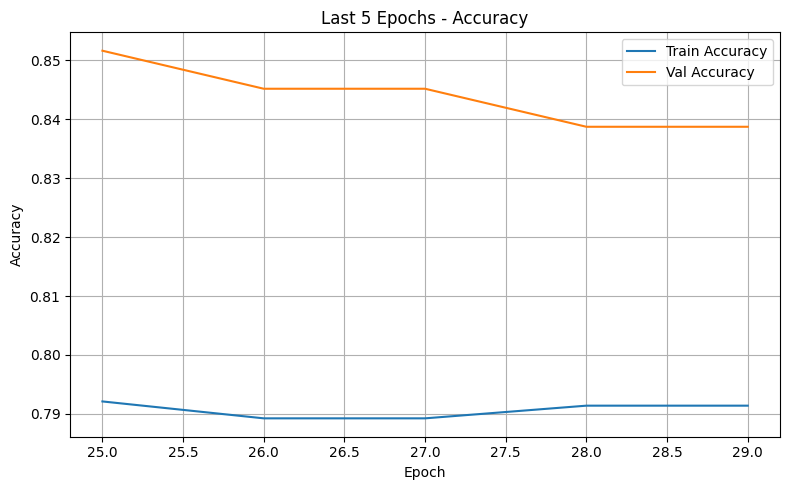

In [14]:
# plot last 5 epochs of accuracy
plt.figure(figsize=(8,5))
epochs_range = range(len(fit.history['accuracy']) - 5, len(fit.history['accuracy']))
plt.plot(epochs_range, fit.history['accuracy'][-5:], label='Train Accuracy')
plt.plot(epochs_range, fit.history['val_accuracy'][-5:], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Last 5 Epochs - Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('last_5_epochs_accuracy.png')
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


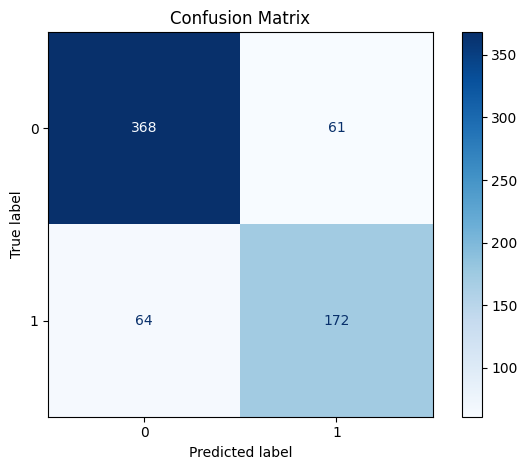

In [15]:
# confusion matrix
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()